<a href="https://colab.research.google.com/github/Redcoder815/Machine_learning_phitron/blob/main/47ML_assignment_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np

In [ ]:
df = pd.read_csv('/content/titanic_data_updated.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,no,second,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,yes,first,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,no,third,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,yes,first,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# Question 1 (10 Marks)
Load the Titanic dataset and display:
- Dataset shape
- First 10 rows
- 5 random samples

In [ ]:
print(df.shape)

print(df.head(10))

df.sample(5)

(891, 12)
   PassengerId Survived  Pclass  \
0            1       no   third   
1            2      yes   first   
2            3      yes   third   
3            4      yes   first   
4            5       no   third   
5            6       no   third   
6            7       no   first   
7            8       no   third   
8            9      yes   third   
9           10      yes  second   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                            McCarthy, Mr. Timothy J    male  54.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
76,77,no,third,"Staneff, Mr. Ivan",male,NaN,0,0,349208,7.8958,NaN,S
679,680,yes,first,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
822,823,no,first,"Reuchlin, Jonkheer. John George",male,38.0,0,0,19972,0.0000,NaN,S
499,500,no,third,"Svensson, Mr. Olof",male,24.0,0,0,350035,7.7958,NaN,S
296,297,no,third,"Hanna, Mr. Mansour",male,23.5,0,0,2693,7.2292,NaN,C


# Question 2 (10 Marks)
Perform feature screening on the Titanic dataset by:
- Finding total missing values
- Finding duplicate rows
- Removing duplicate rows permanently

In [ ]:
print(df.isnull().sum())
dup_rows = df[df.duplicated()]
print(dup_rows)

# df.duplicated().sum()

df.drop_duplicates(inplace=True)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Empty DataFrame
Columns: [PassengerId, Survived, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked]
Index: []


# Question 3 (10 Marks)
Perform statistical profiling of the Titanic dataset and display:
- Dataset information
- Statistical summary of numerical columns

Also write 2 observations from the output.


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    object 
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 83.7+ KB


,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,29.699118,0.523008,0.381594,32.204208
std,257.353842,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,38.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


1.Age column has 714 non null rows and data type float64

2.Maximum age is 80

# Question 4 (10 Marks)
Perform univariate categorical analysis on the Survived column by:
- Creating a countplot
- Calculating percentage distribution
- Creating a pie chart

Write 2 insights from the analysis.

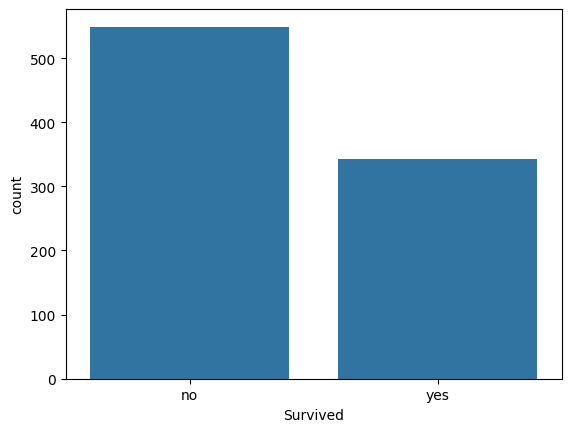

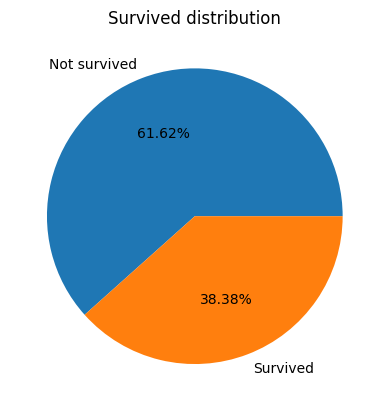

In [ ]:
sns.countplot(data = df, x = 'Survived')
plt.show()

# survived_count = (df['Survived'].value_counts())/len(df)
# print(survived_count)

survived_count = df['Survived'].value_counts(normalize=True)
# print(survived_count)

survived_labels = ['Not survived', 'Survived']

plt.pie(survived_count,labels=survived_labels,autopct='%1.2f%%')
plt.title('Survived distribution')
plt.show()

1.More than 500 people died

2.Around 61.62% people died

# Question 5 (10 Marks)
Perform univariate numerical analysis on the Age column by:
- Creating a histogram
- Creating a KDE plot

Write 2 observations from the plots.


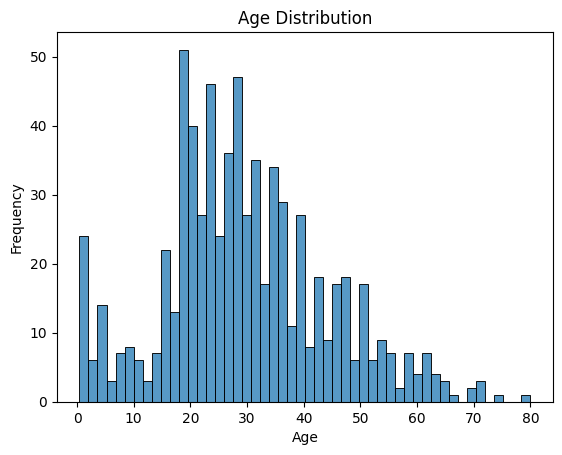

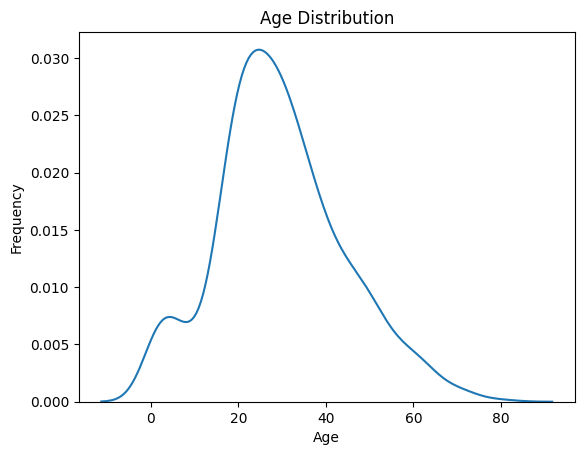

In [ ]:
sns.histplot(data = df, x = 'Age', bins = 50)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

sns.kdeplot(data=df,x='Age')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

1.Most of the people age is 15-40

2.Right skewed distribution

# Question 6 (10 Marks)
Perform multivariate analysis between Sex and Survived using a countplot with hue.

Also calculate normalized survival ratios using groupby().

Write 2 insights from the analysis.


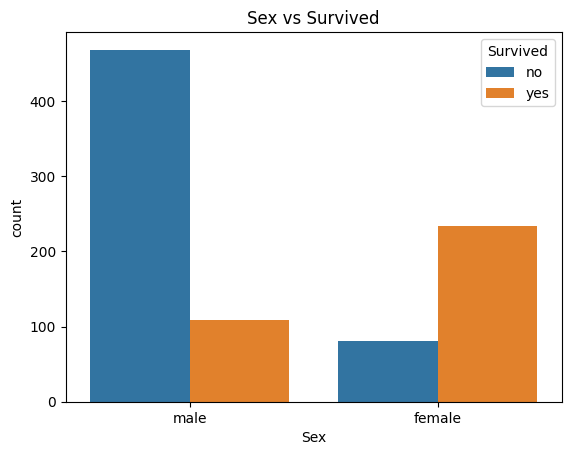

Sex     Survived
female  yes         74.203822
        no          25.796178
male    no          81.109185
        yes         18.890815
Name: proportion, dtype: float64


In [ ]:
sns.countplot(data=df,x='Sex',hue='Survived')
plt.title('Sex vs Survived')
plt.show()

survival_ratio = df.groupby('Sex')['Survived'].value_counts(normalize=True)
print(survival_ratio * 100)
# print(survival_ratio)

1. More female survived than male

2. 81.1% male died

# Question 7 (10 Marks)

Create a barplot showing the relationship between Pclass and Fare.

Write 2 observations from the visualization.


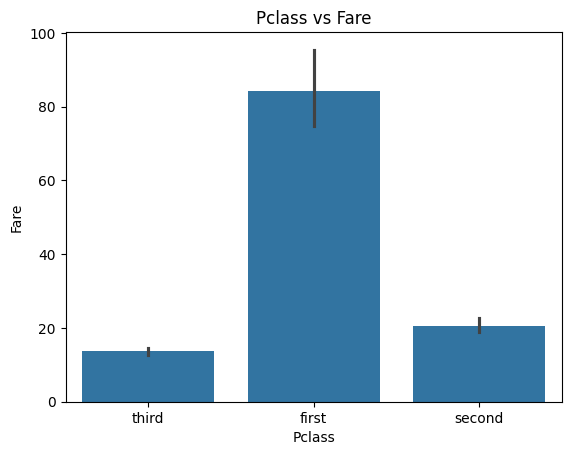

In [ ]:
sns.barplot(data=df,x='Pclass',y='Fare')
plt.title('Pclass vs Fare')
plt.xlabel('Pclass')
plt.ylabel('Fare')
plt.show()

1.First class average cost is most high.

2.Third class average cost less than 20

# Question 8 (10 Marks)

Create a KDE plot to compare the Age distribution of survived and non-survived passengers.

Write 2 insights from the graph.


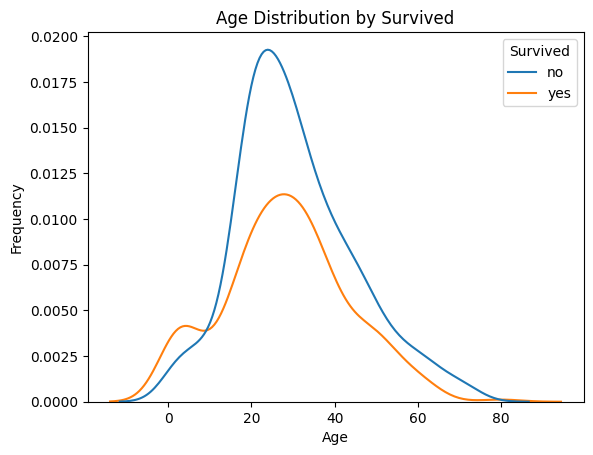

In [ ]:
sns.kdeplot(data = df, x = 'Age', hue = 'Survived')
plt.title('Age Distribution by Survived')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

1.Between survived and non-survived, non-survived people are more

2.Children survived rate is more than mortality rate

# Question 9 (10 Marks)
Perform feature engineering and train-test split by:
- Dropping PassengerId, Name, and Ticket columns
- Separating features (X) and target (y)
- Splitting the dataset using test_size=0.2 and random_state=42

Display the shapes of train and test datasets.


In [ ]:
df.drop(['PassengerId','Name','Ticket'],axis=1,inplace=True)

X = df.drop(['Survived'],axis=1)
y = df['Survived']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(712, 8)
(712,)
(179, 8)
(179,)


# Question 10 (10 Marks)
Handle missing values in the Titanic dataset by:
- Imputing missing Age values using SimpleImputer with mean strategy
- Imputing missing Embarked values using most frequent strategy
- Imputing missing Cabin values using constant strategy with "Missing"

Finally, check whether any missing values remain.


In [ ]:
# age imputer
age_imputer = SimpleImputer(missing_values=np.nan , strategy='mean')
age_imputer.fit(X_train[['Age']])
X_train['Age'] = age_imputer.transform(X_train[['Age']]).ravel()
X_test['Age'] = age_imputer.transform(X_test[['Age']]).ravel()

#embarked imputor
embarked_imputer = SimpleImputer(missing_values=np.nan , strategy='most_frequent')
embarked_imputer.fit(X_train[['Embarked']])
X_train['Embarked']= embarked_imputer.transform(X_train[['Embarked']]).ravel()
X_test['Embarked'] = embarked_imputer.transform(X_test[['Embarked']]).ravel()

#cabin imputer
cabin_imputer = SimpleImputer(missing_values=np.nan , strategy='constant',fill_value='Missing',add_indicator=True)
cabin_imputer.fit(X_train[['Cabin']])
X_train[['Cabin','Cabin_missing']]= cabin_imputer.transform(X_train[['Cabin']])
X_test[['Cabin','Cabin_missing']] = cabin_imputer.transform(X_test[['Cabin']])

print(X_train.isnull().sum())

X_test.isnull().sum()

Pclass           0
Sex              0
Age              0
SibSp            0
Parch            0
Fare             0
Cabin            0
Embarked         0
Cabin_missing    0
dtype: int64


,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,0
Embarked,0
Cabin_missing,0
